In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Available targets: ['0050.TW', '00632R.TW', '00679B.TW', '2303.TW', '2308.TW', '2317.TW', '2330.TW', '2376.TW', '2377.TW', '2382.TW', '2454.TW', '3711.TW']
Missing targets: []
Number of binary event features: 50
Evaluating 0050.TW...
Evaluating 00632R.TW...
Evaluating 00679B.TW...
Evaluating 2303.TW...
Evaluating 2308.TW...
Evaluating 2317.TW...
Evaluating 2330.TW...
Evaluating 2376.TW...
Evaluating 2377.TW...
Evaluating 2382.TW...
Evaluating 2454.TW...
Evaluating 3711.TW...


,target,event,n,mean_ret_h1,median_ret_h1,hit_rate_h1,std_h1,mean_ret_h2,median_ret_h2,hit_rate_h2,std_h2,mean_ret_h3,median_ret_h3,hit_rate_h3,std_h3
0,0050.TW,long_posts,22,0.003619,0.003769,0.636364,0.014891,0.003294,0.000607,0.545455,0.020313,0.005170,0.005059,0.772727,0.023034
1,0050.TW,posts_very_high,240,0.001909,0.002406,0.587500,0.010094,0.002786,0.003215,0.558333,0.016954,0.003647,0.003779,0.583333,0.020588
2,0050.TW,has_market_brag,175,0.001897,0.001525,0.571429,0.008497,0.002095,0.003052,0.560000,0.012873,0.001933,0.000618,0.520000,0.015070
3,0050.TW,volume_drop,387,0.001854,0.000000,0.498708,0.012661,0.003537,0.002275,0.537468,0.017346,0.004749,0.002439,0.545220,0.020871
4,0050.TW,high_emotion,166,0.001836,0.000000,0.493976,0.010618,0.003820,0.003241,0.572289,0.017996,0.003639,0.003122,0.584337,0.022815
5,0050.TW,attack_heavy,414,0.001595,0.001347,0.553140,0.009850,0.002899,0.002212,0.553140,0.014676,0.004359,0.002911,0.582126,0.018037
6,0050.TW,brag_heavy,32,0.001589,0.002847,0.656250,0.008117,0.002778,0.004476,0.656250,0.011512,0.001366,0.002571,0.562500,0.014139
7,0050.TW,has_action,271,0.001490,0.000484,0.512915,0.012028,0.002232,0.002645,0.571956,0.018008,0.004387,0.003521,0.594096,0.021607
8,0050.TW,sig_potus,120,0.001441,0.000919,0.525000,0.008390,0.004718,0.002315,0.591667,0.013864,0.005804,0.003463,0.575000,0.018489
9,0050.TW,tariff_rising,20,0.001436,0.001829,0.550000,0.007165,0.001034,-0.001811,0.350000,0.009632,0.000617,-0.000299,0.400000,0.013078


Saved: ./output/taiwan_event_return_analysis_all_targets.csv


,event,avg_mean_ret_h1,avg_mean_ret_h2,avg_mean_ret_h3,avg_hit_rate_h1,avg_hit_rate_h2,avg_hit_rate_h3,avg_n,target_count,score_h1
20,long_posts,0.003993,0.003446,0.004663,0.475207,0.458678,0.520661,22.0,11,0.405838
33,sig_potus,0.002412,0.005997,0.007472,0.477273,0.523485,0.537879,120.0,11,0.266440
13,has_market_brag,0.001959,0.002042,0.002055,0.482078,0.493506,0.478961,175.0,11,0.229731
27,posts_very_high,0.001827,0.002879,0.003818,0.476515,0.498864,0.509470,240.0,11,0.214072
0,attack_heavy,0.001604,0.002892,0.004176,0.471454,0.500000,0.517347,414.0,11,0.192177
8,has_attack,0.001410,0.002493,0.003446,0.460809,0.492127,0.507090,1045.0,11,0.171367
39,volume_drop,0.001560,0.003219,0.004140,0.453136,0.486023,0.508104,387.0,11,0.168707
12,has_iran,0.001586,0.001877,0.001389,0.458069,0.486963,0.498238,129.0,11,0.165368
34,silence_day,0.001498,0.002892,0.004057,0.435632,0.468919,0.482537,721.0,11,0.151246
24,positive_heavy,0.001129,0.002141,0.003173,0.460495,0.487632,0.503810,871.0,11,0.141096


Saved: ./output/taiwan_event_return_analysis_summary.csv


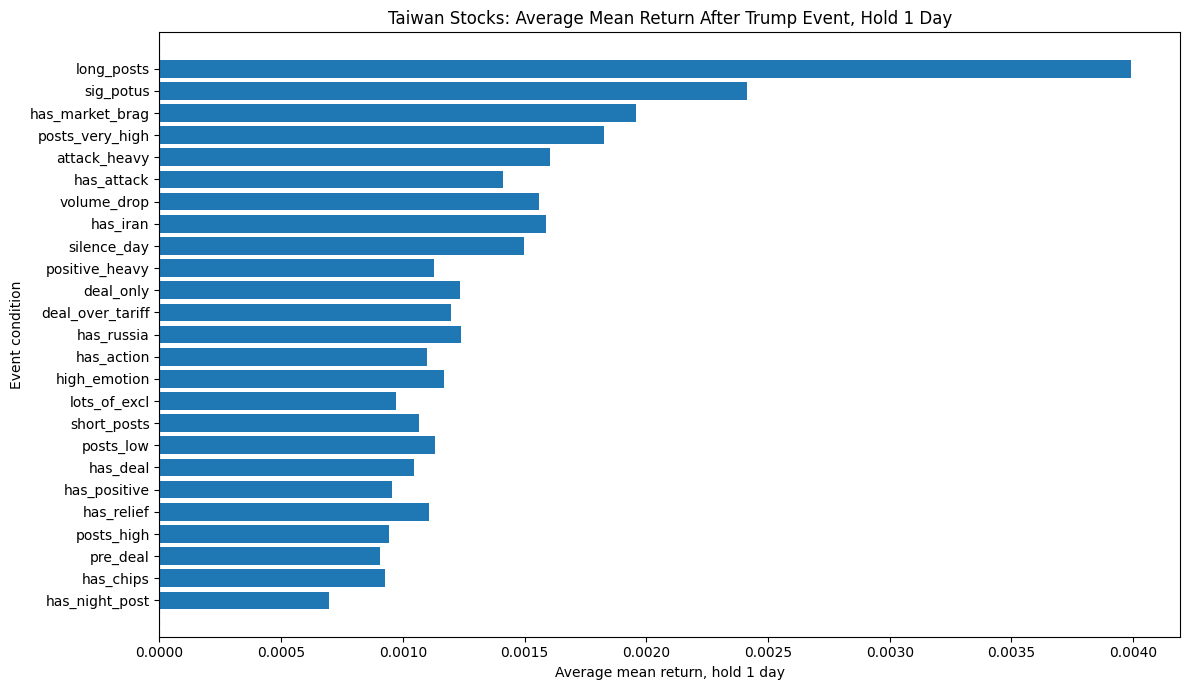

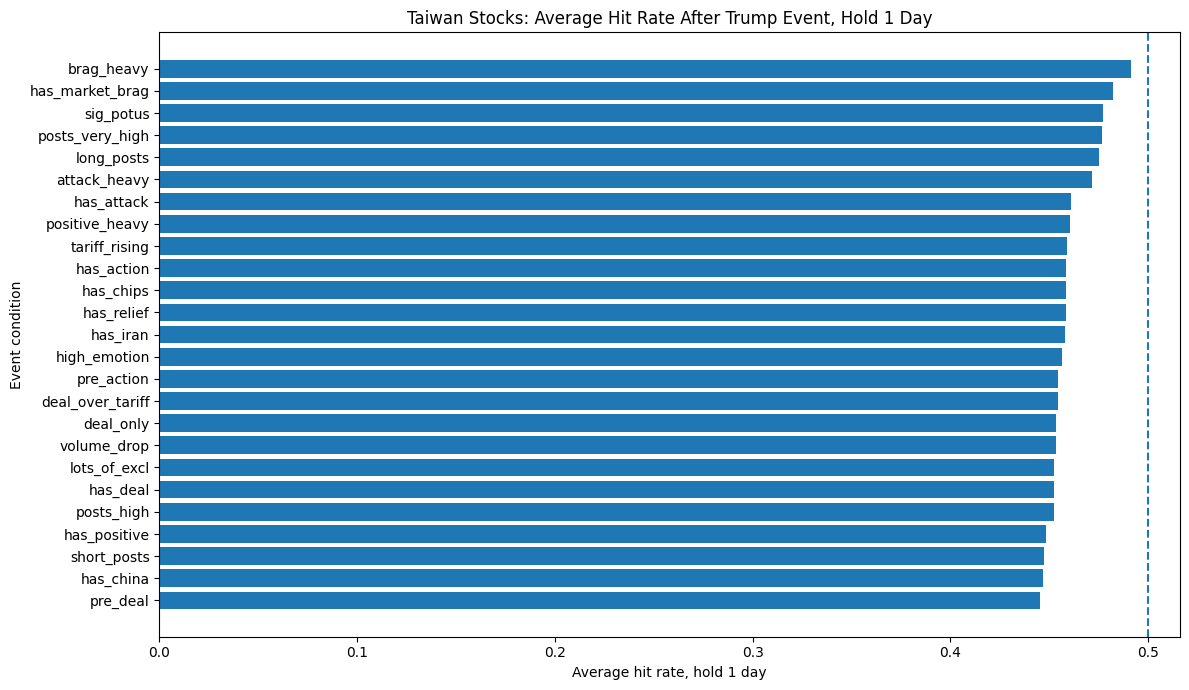

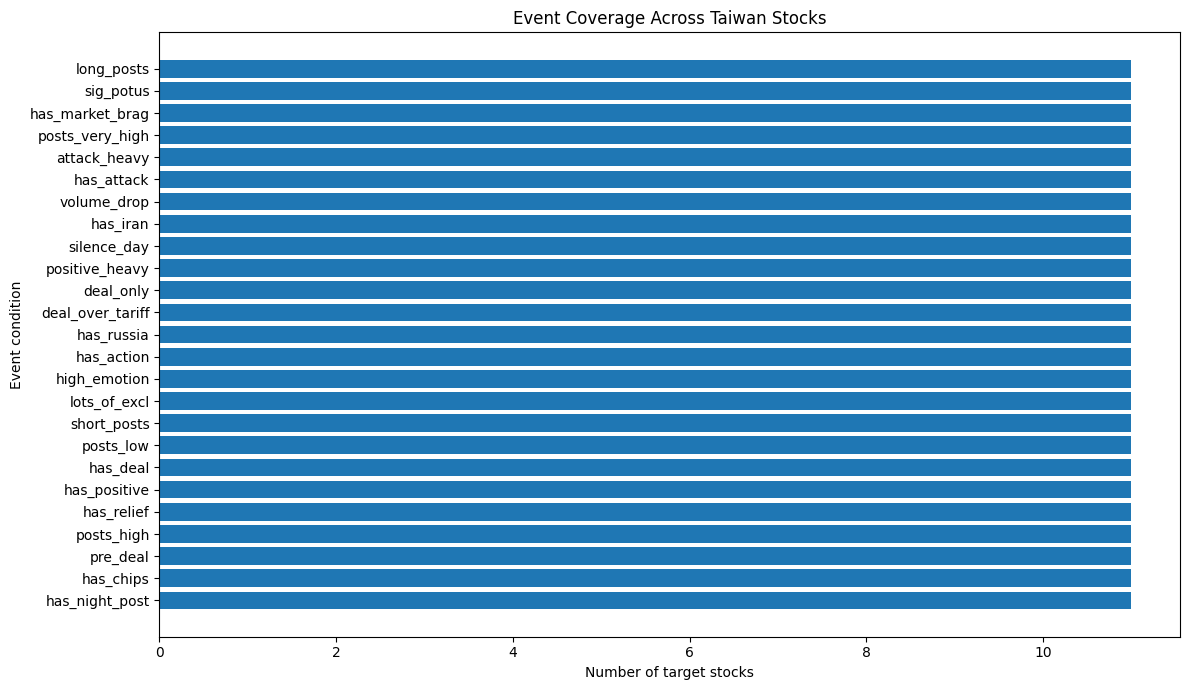

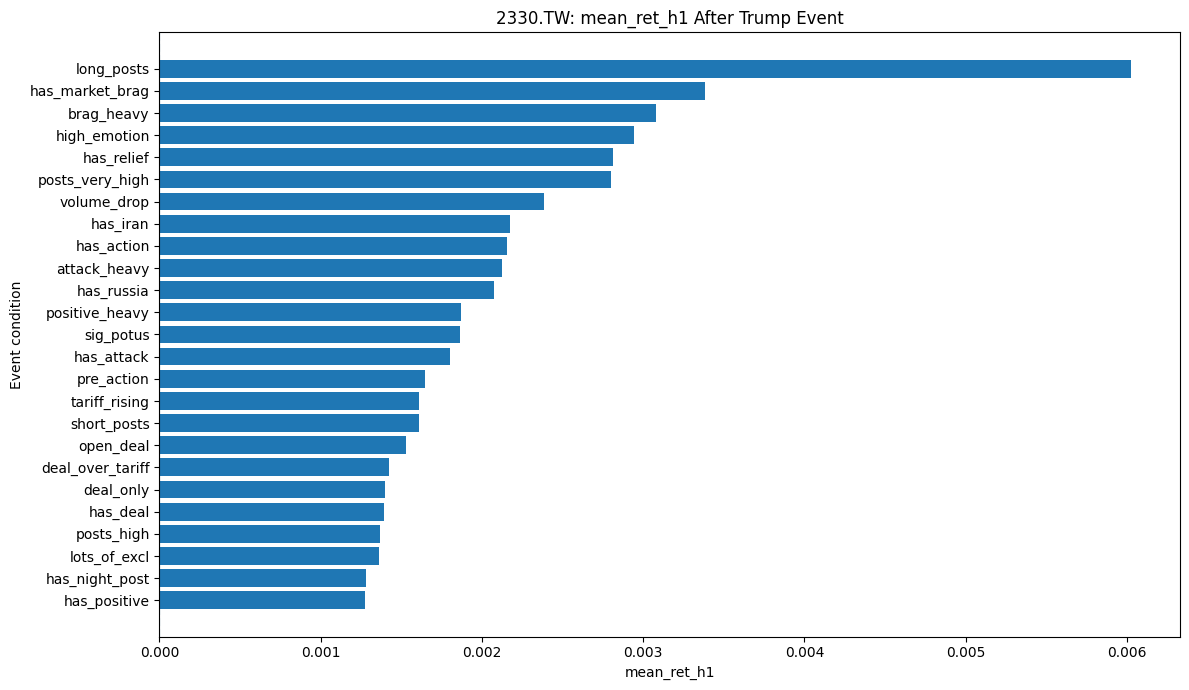

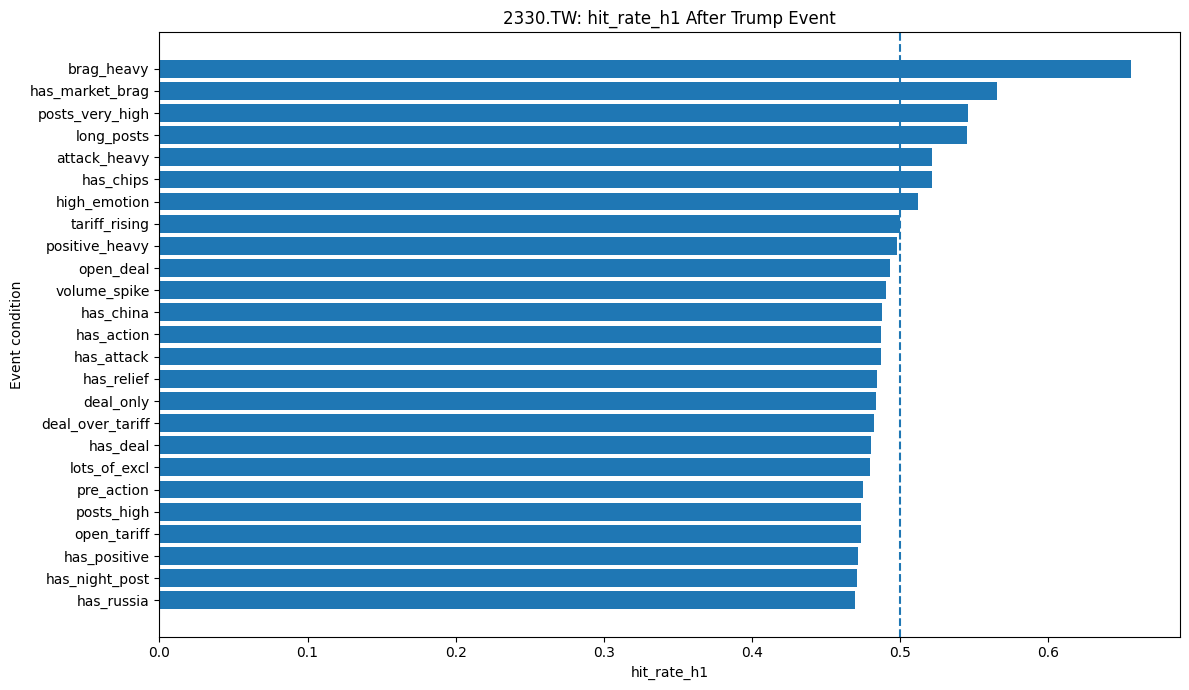

,event,avg_mean_ret_h1,avg_mean_ret_h2,avg_mean_ret_h3,avg_hit_rate_h1,avg_hit_rate_h2,avg_hit_rate_h3,avg_n,target_count,score_h1
30,pre_relief,0.000269,0.003385,0.009141,0.441558,0.529221,0.555195,28.0,11,0.002169


Saved: ./output/valuable_trump_events_for_taiwan_stocks.csv


In [2]:
# =====================================================
# 0. 參數
# =====================================================

TARGETS = [
    "0050.TW", "00632R.TW", "00679B.TW",
    "2303.TW", "2308.TW", "2317.TW", "2330.TW",
    "2376.TW", "2377.TW", "2382.TW", "2454.TW", "3711.TW"
]

PRICE_PATH = "taiwan_market_data/global_prices.csv"
EVENT_PATH = "./output/trump_daily_binary_event_features.csv"

HOLD_DAYS = [1, 2, 3]
MIN_EVENT_N = 10
TOP_N = 25

# =====================================================
# 1. 準備價格資料
# =====================================================

price_df = pd.read_csv(PRICE_PATH)
price_df["Date"] = pd.to_datetime(price_df["Date"])
price_df = price_df.sort_values("Date").set_index("Date")

available_targets = [t for t in TARGETS if t in price_df.columns]
missing_targets = [t for t in TARGETS if t not in price_df.columns]

print("Available targets:", available_targets)
print("Missing targets:", missing_targets)

# =====================================================
# 2. 準備事件資料
# =====================================================

event_df = pd.read_csv(EVENT_PATH)
event_df["trump_date"] = pd.to_datetime(event_df["trump_date"])
event_df = event_df.sort_values("trump_date").set_index("trump_date")

exclude_cols = {
    "post_count", "tariff_count", "deal_count", "relief_count",
    "china_count", "taiwan_count", "chips_count", "ai_count",
    "night_post_count", "pre_post_count", "open_post_count",
    "total_excl", "avg_post_len"
}

event_cols = [
    c for c in event_df.columns
    if c not in exclude_cols
    and event_df[c].dropna().isin([0, 1]).all()
]

print(f"Number of binary event features: {len(event_cols)}")

# =====================================================
# 3. 對單一 target 計算事件效果
# =====================================================

def evaluate_single_target(target):
    price = price_df[target].dropna()

    returns = pd.DataFrame(index=price.index)

    for hold in HOLD_DAYS:
        returns[f"ret_h{hold}"] = price.shift(-hold) / price - 1

    data = event_df[event_cols].join(returns, how="inner")

    results = []

    for event in event_cols:
        mask = data[event] == 1
        n = int(mask.sum())

        if n < MIN_EVENT_N:
            continue

        row = {
            "target": target,
            "event": event,
            "n": n,
        }

        for hold in HOLD_DAYS:
            r = data.loc[mask, f"ret_h{hold}"].dropna()

            row[f"mean_ret_h{hold}"] = r.mean()
            row[f"median_ret_h{hold}"] = r.median()
            row[f"hit_rate_h{hold}"] = (r > 0).mean()
            row[f"std_h{hold}"] = r.std()

        results.append(row)

    result_df = pd.DataFrame(results)

    if result_df.empty:
        return result_df

    result_df = result_df.sort_values("mean_ret_h1", ascending=False)
    return result_df

# =====================================================
# 4. 跑全部台股
# =====================================================

all_results = []

for target in available_targets:
    print(f"Evaluating {target}...")
    result = evaluate_single_target(target)
    all_results.append(result)

all_result_df = pd.concat(all_results, ignore_index=True)

display(all_result_df.head(50))

all_result_df.to_csv("./output/taiwan_event_return_analysis_all_targets.csv", index=False)

print("Saved: ./output/taiwan_event_return_analysis_all_targets.csv")

# =====================================================
# 5. 找出跨股票最有價值的事件
# =====================================================

summary = (
    all_result_df
    .groupby("event")
    .agg(
        avg_mean_ret_h1=("mean_ret_h1", "mean"),
        avg_mean_ret_h2=("mean_ret_h2", "mean"),
        avg_mean_ret_h3=("mean_ret_h3", "mean"),
        avg_hit_rate_h1=("hit_rate_h1", "mean"),
        avg_hit_rate_h2=("hit_rate_h2", "mean"),
        avg_hit_rate_h3=("hit_rate_h3", "mean"),
        avg_n=("n", "mean"),
        target_count=("target", "nunique"),
    )
    .reset_index()
)

summary["score_h1"] = (
    summary["avg_mean_ret_h1"] * 100
    + (summary["avg_hit_rate_h1"] - 0.5)
    + np.log1p(summary["avg_n"]) * 0.01
)

summary = summary.sort_values("score_h1", ascending=False)

display(summary.head(30))

summary.to_csv("./output/taiwan_event_return_analysis_summary.csv", index=False)

print("Saved: ./output/taiwan_event_return_analysis_summary.csv")

# =====================================================
# 6. 畫圖：跨股票平均報酬 Top events
# =====================================================

plot_df = summary.head(TOP_N).copy()

plt.figure(figsize=(12, 7))
plt.barh(plot_df["event"], plot_df["avg_mean_ret_h1"])
plt.axvline(0, linestyle="--")
plt.xlabel("Average mean return, hold 1 day")
plt.ylabel("Event condition")
plt.title("Taiwan Stocks: Average Mean Return After Trump Event, Hold 1 Day")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# =====================================================
# 7. 畫圖：跨股票平均勝率 Top events
# =====================================================

plot_df = summary.sort_values("avg_hit_rate_h1", ascending=False).head(TOP_N)

plt.figure(figsize=(12, 7))
plt.barh(plot_df["event"], plot_df["avg_hit_rate_h1"])
plt.axvline(0.5, linestyle="--")
plt.xlabel("Average hit rate, hold 1 day")
plt.ylabel("Event condition")
plt.title("Taiwan Stocks: Average Hit Rate After Trump Event, Hold 1 Day")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# =====================================================
# 8. 畫圖：事件在多少檔股票上有資料
# =====================================================

plot_df = summary.sort_values("target_count", ascending=False).head(TOP_N)

plt.figure(figsize=(12, 7))
plt.barh(plot_df["event"], plot_df["target_count"])
plt.xlabel("Number of target stocks")
plt.ylabel("Event condition")
plt.title("Event Coverage Across Taiwan Stocks")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# =====================================================
# 9. 單一股票畫圖函式
# =====================================================

def plot_target_result(target, metric="mean_ret_h1", top_n=25):
    df = all_result_df[all_result_df["target"] == target].copy()

    if df.empty:
        print(f"No result for {target}")
        return

    df = df.sort_values(metric, ascending=False).head(top_n)

    plt.figure(figsize=(12, 7))
    plt.barh(df["event"], df[metric])

    if "hit_rate" in metric:
        plt.axvline(0.5, linestyle="--")
    else:
        plt.axvline(0, linestyle="--")

    plt.xlabel(metric)
    plt.ylabel("Event condition")
    plt.title(f"{target}: {metric} After Trump Event")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# 使用範例
plot_target_result("2330.TW", metric="mean_ret_h1")
plot_target_result("2330.TW", metric="hit_rate_h1")

# =====================================================
# 10. 找出最適合深度學習保留的事件
# =====================================================

valuable_events = summary[
    (summary["target_count"] >= 6) &
    (summary["avg_n"] >= 20) &
    (
        (summary["avg_hit_rate_h1"] > 0.55) |
        (summary["avg_hit_rate_h2"] > 0.55) |
        (summary["avg_hit_rate_h3"] > 0.55)
    ) &
    (
        (summary["avg_mean_ret_h1"] > 0.001) |
        (summary["avg_mean_ret_h2"] > 0.001) |
        (summary["avg_mean_ret_h3"] > 0.001)
    )
].copy()

valuable_events = valuable_events.sort_values("score_h1", ascending=False)

display(valuable_events)

valuable_events.to_csv("./output/valuable_trump_events_for_taiwan_stocks.csv", index=False)

print("Saved: ./output/valuable_trump_events_for_taiwan_stocks.csv")

Available targets: ['0050.TW', '00632R.TW', '00679B.TW', '2303.TW', '2308.TW', '2317.TW', '2330.TW', '2376.TW', '2377.TW', '2382.TW', '2454.TW', '3711.TW']
Missing targets: []
Binary event features: 50
Control factor count: 16

Evaluating target: 0050.TW

Evaluating target: 00632R.TW

Evaluating target: 00679B.TW
Skip 00679B.TW: Too few samples for 00679B.TW, hold=1, samples=0

Evaluating target: 2303.TW

Evaluating target: 2308.TW

Evaluating target: 2317.TW

Evaluating target: 2330.TW

Evaluating target: 2376.TW

Evaluating target: 2377.TW

Evaluating target: 2382.TW

Evaluating target: 2454.TW

Evaluating target: 3711.TW

Top period-event-target residual influence:
   target     period period_start period_end           event  n  raw_gap_h1  resid_gap_h1  resid_hit_h1  resid_abs_lift_h1  event_resid_mean_h1  nonevent_resid_mean_h1  raw_gap_h2  resid_gap_h2  resid_hit_h2  resid_abs_lift_h2  event_resid_mean_h2  nonevent_resid_mean_h2  raw_gap_h3  resid_gap_h3  resid_hit_h3  resid_abs_

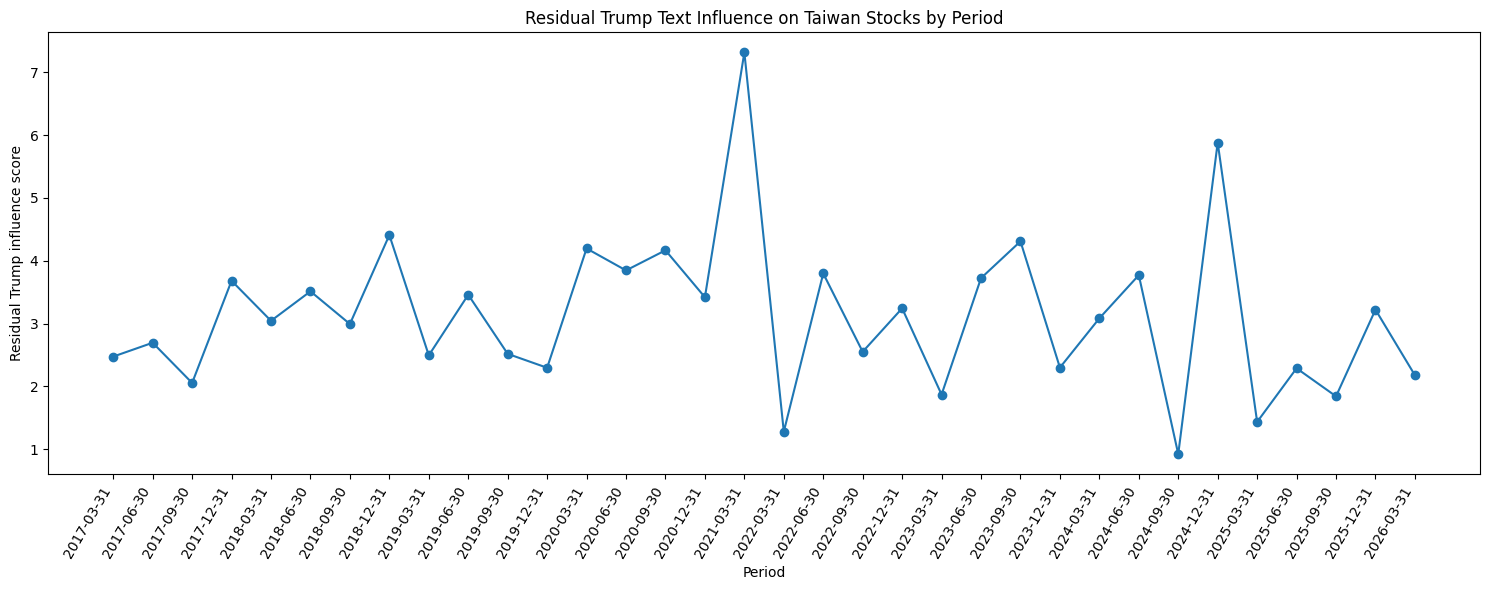

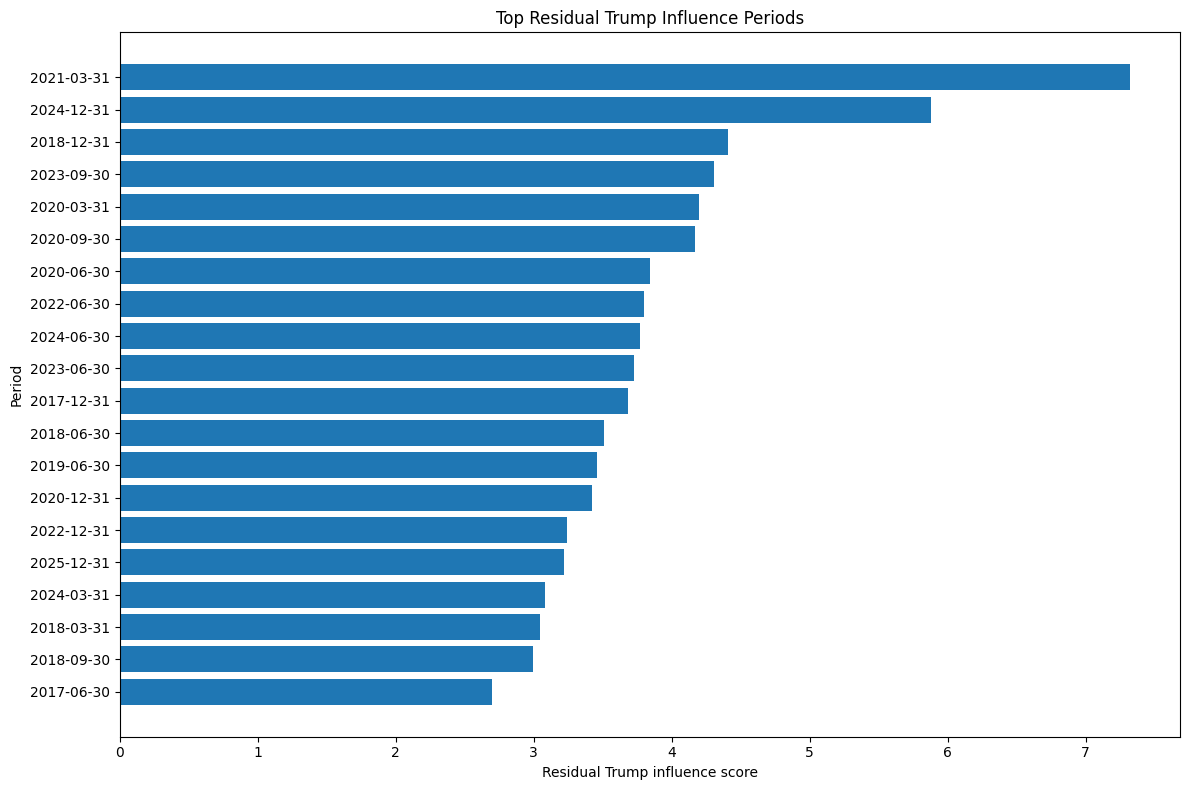

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# =====================================================
# 0. Config
# =====================================================

TARGETS = [
    "0050.TW", "00632R.TW",
    "2303.TW", "2308.TW", "2317.TW", "2330.TW",
    "2376.TW", "2377.TW", "2382.TW", "2454.TW", "3711.TW"
]

PRICE_PATH = "taiwan_market_data/global_prices.csv"
EVENT_PATH = "./output/trump_daily_binary_event_features.csv"
OUTPUT_DIR = "./output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

HOLD_DAYS = [1, 2, 3]

# pandas 新版不要用 Q，要用 QE
PERIOD_FREQ = "QE"      # 季度；可改 "YE" 年度、"ME" 月度
MIN_PERIOD_EVENT_N = 5
TOP_EVENTS_PER_PERIOD = 5
MIN_REGRESSION_SAMPLES = 100

CONTROL_PRICE_COLS = [
    "0050.TW",
    "TSM",
    "^GSPC",
    "^NDX",
    "^SOX",
    "TWD=X",
]

CONTROL_DIFF_COLS = [
    "^VIX",
    "^TNX",
]


# =====================================================
# 1. Load data
# =====================================================

price_df = pd.read_csv(PRICE_PATH)
price_df["Date"] = pd.to_datetime(price_df["Date"])
price_df = price_df.sort_values("Date").set_index("Date")

event_df = pd.read_csv(EVENT_PATH)
event_df["trump_date"] = pd.to_datetime(event_df["trump_date"])
event_df = event_df.sort_values("trump_date").set_index("trump_date")

available_targets = [t for t in TARGETS if t in price_df.columns]
missing_targets = [t for t in TARGETS if t not in price_df.columns]

print("Available targets:", available_targets)
print("Missing targets:", missing_targets)


# =====================================================
# 2. Select Trump event columns
# =====================================================

exclude_cols = {
    "post_count", "tariff_count", "deal_count", "relief_count",
    "china_count", "taiwan_count", "chips_count", "ai_count",
    "night_post_count", "pre_post_count", "open_post_count",
    "total_excl", "avg_post_len"
}

event_cols = [
    c for c in event_df.columns
    if c not in exclude_cols
    and event_df[c].dropna().isin([0, 1]).all()
]

print("Binary event features:", len(event_cols))


# =====================================================
# 3. Build control factors
# =====================================================

controls = pd.DataFrame(index=price_df.index)

for col in CONTROL_PRICE_COLS:
    if col in price_df.columns:
        controls[f"{col}_ret"] = price_df[col].pct_change()

for col in CONTROL_DIFF_COLS:
    if col in price_df.columns:
        controls[f"{col}_diff"] = price_df[col].diff()

base_control_cols = list(controls.columns)

for col in base_control_cols:
    controls[f"{col}_lag1"] = controls[col].shift(1)

controls = controls.replace([np.inf, -np.inf], np.nan)

print("Control factor count:", controls.shape[1])


# =====================================================
# 4. Residual return function
# =====================================================

residual_cache = {}

def build_future_return(price_series, hold):
    return price_series.shift(-hold) / price_series - 1


def compute_residual_return(target, hold):
    cache_key = (target, hold)

    if cache_key in residual_cache:
        return residual_cache[cache_key]

    price = price_df[target].dropna()

    y = build_future_return(price, hold).rename("future_ret")

    df = pd.concat([y, controls], axis=1, sort=False).dropna()

    if len(df) < MIN_REGRESSION_SAMPLES:
        raise ValueError(
            f"Too few samples for {target}, hold={hold}, samples={len(df)}"
        )

    X = df.drop(columns=["future_ret"])
    y = df["future_ret"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

    model.fit(X, y)

    pred = pd.Series(
        model.predict(X),
        index=df.index,
        name=f"pred_by_controls_h{hold}"
    )

    residual = y - pred
    residual.name = f"residual_ret_h{hold}"

    out = pd.DataFrame({
        f"raw_ret_h{hold}": y,
        f"pred_by_controls_h{hold}": pred,
        f"residual_ret_h{hold}": residual,
    })

    residual_cache[cache_key] = out

    return out


# =====================================================
# 5. Period-level residual Trump influence
# =====================================================

period_rows = []
valid_targets = []

for target in available_targets:
    print(f"\nEvaluating target: {target}")

    residual_frames = []

    try:
        for hold in HOLD_DAYS:
            residual_frames.append(compute_residual_return(target, hold))
    except ValueError as e:
        print(f"Skip {target}: {e}")
        continue

    valid_targets.append(target)

    ret_df = pd.concat(residual_frames, axis=1, sort=False)

    data = event_df[event_cols].join(ret_df, how="inner")

    for period, g in data.groupby(pd.Grouper(freq=PERIOD_FREQ)):
        if g.empty:
            continue

        period_start = g.index.min()
        period_end = g.index.max()

        for event in event_cols:
            mask = g[event] == 1
            n = int(mask.sum())

            if n < MIN_PERIOD_EVENT_N:
                continue

            row = {
                "target": target,
                "period": period,
                "period_start": period_start,
                "period_end": period_end,
                "event": event,
                "n": n,
            }

            score_parts = []

            for hold in HOLD_DAYS:
                resid_col = f"residual_ret_h{hold}"
                raw_col = f"raw_ret_h{hold}"

                event_resid = g.loc[mask, resid_col].dropna()
                nonevent_resid = g.loc[~mask, resid_col].dropna()

                event_raw = g.loc[mask, raw_col].dropna()
                nonevent_raw = g.loc[~mask, raw_col].dropna()

                if (
                    len(event_resid) < MIN_PERIOD_EVENT_N
                    or len(nonevent_resid) < MIN_PERIOD_EVENT_N
                ):
                    continue

                resid_gap = event_resid.mean() - nonevent_resid.mean()
                raw_gap = event_raw.mean() - nonevent_raw.mean()

                resid_hit = (event_resid > 0).mean()

                abs_lift = (
                    event_resid.abs().mean()
                    - nonevent_resid.abs().mean()
                )

                row[f"raw_gap_h{hold}"] = raw_gap
                row[f"resid_gap_h{hold}"] = resid_gap
                row[f"resid_hit_h{hold}"] = resid_hit
                row[f"resid_abs_lift_h{hold}"] = abs_lift
                row[f"event_resid_mean_h{hold}"] = event_resid.mean()
                row[f"nonevent_resid_mean_h{hold}"] = nonevent_resid.mean()

                part_score = (
                    abs(resid_gap) * 100
                    + abs(resid_hit - 0.5)
                    + max(abs_lift, 0) * 50
                    + np.log1p(n) * 0.01
                )

                score_parts.append(part_score)

            if len(score_parts) == 0:
                continue

            row["period_residual_influence_score"] = np.mean(score_parts)

            period_rows.append(row)


period_detail_df = pd.DataFrame(period_rows)

if period_detail_df.empty:
    raise ValueError(
        "No period-level result. Try lowering MIN_PERIOD_EVENT_N or use PERIOD_FREQ='YE'."
    )

period_detail_df = period_detail_df.sort_values(
    "period_residual_influence_score",
    ascending=False
)

detail_path = f"{OUTPUT_DIR}/trump_residual_period_detail.csv"
period_detail_df.to_csv(detail_path, index=False, encoding="utf-8-sig")

print("\nTop period-event-target residual influence:")
print(period_detail_df.head(50).to_string(index=False))
print("Saved:", detail_path)


# =====================================================
# 6. Period summary: 取每個 period 前 TOP_EVENTS_PER_PERIOD 平均
# =====================================================

top_period_events = []

for period, g in period_detail_df.groupby("period"):
    top_g = (
        g.sort_values(
            "period_residual_influence_score",
            ascending=False
        )
        .head(TOP_EVENTS_PER_PERIOD)
        .copy()
    )

    top_period_events.append(top_g)

top_period_events_df = pd.concat(
    top_period_events,
    axis=0,
    ignore_index=True,
    sort=False
)

period_summary_df = (
    top_period_events_df
    .groupby("period", as_index=False)
    .agg(
        period_start=("period_start", "min"),
        period_end=("period_end", "max"),
        period_residual_influence_score=("period_residual_influence_score", "mean"),
        max_period_score=("period_residual_influence_score", "max"),
        top_event=("event", "first"),
        top_target=("target", "first"),
        top_event_n=("n", "first"),
        top_event_gap_h1=("resid_gap_h1", "first"),
        top_event_hit_h1=("resid_hit_h1", "first"),
        qualified_top_event_count=("event", "count"),
    )
    .sort_values("period_residual_influence_score", ascending=False)
)

summary_path = f"{OUTPUT_DIR}/trump_residual_period_summary.csv"
period_summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("\nTop residual Trump influence periods:")
print(period_summary_df.head(30).to_string(index=False))
print("Saved:", summary_path)


# =====================================================
# 7. Period × target summary
# =====================================================

period_target_summary_df = (
    period_detail_df
    .groupby(["period", "target"], as_index=False)
    .agg(
        target_period_score=("period_residual_influence_score", "mean"),
        max_target_period_score=("period_residual_influence_score", "max"),
        event_count=("event", "count"),
    )
    .sort_values("target_period_score", ascending=False)
)

period_target_path = f"{OUTPUT_DIR}/trump_residual_period_target_summary.csv"
period_target_summary_df.to_csv(period_target_path, index=False, encoding="utf-8-sig")

print("\nTop period-target residual influence:")
print(period_target_summary_df.head(30).to_string(index=False))
print("Saved:", period_target_path)


# =====================================================
# 8. Plot: period influence
# =====================================================

plot_df = period_summary_df.sort_values("period").copy()
plot_df["period_label"] = plot_df["period"].astype(str)

plt.figure(figsize=(15, 6))
plt.plot(
    plot_df["period_label"],
    plot_df["period_residual_influence_score"],
    marker="o"
)
plt.xticks(rotation=60, ha="right")
plt.xlabel("Period")
plt.ylabel("Residual Trump influence score")
plt.title("Residual Trump Text Influence on Taiwan Stocks by Period")
plt.tight_layout()
plt.show()


# =====================================================
# 9. Plot: top periods
# =====================================================

top_plot = period_summary_df.head(20).copy()
top_plot["period_label"] = top_plot["period"].astype(str)

plt.figure(figsize=(12, 8))
plt.barh(
    top_plot["period_label"],
    top_plot["period_residual_influence_score"]
)
plt.xlabel("Residual Trump influence score")
plt.ylabel("Period")
plt.title("Top Residual Trump Influence Periods")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# =====================================================
# 10. Helper: inspect one period
# =====================================================

def show_period(period_label, top_n=30):
    """
    PERIOD_FREQ="QE" 時：
        show_period("2018Q2")
        show_period("2020Q1")
        show_period("2025Q2")
    """

    temp = period_detail_df.copy()

    if PERIOD_FREQ == "QE":
        temp["period_key"] = temp["period"].dt.to_period("Q")
        target_period = pd.Period(period_label, freq="Q")
    elif PERIOD_FREQ == "YE":
        temp["period_key"] = temp["period"].dt.to_period("Y")
        target_period = pd.Period(period_label, freq="Y")
    elif PERIOD_FREQ == "ME":
        temp["period_key"] = temp["period"].dt.to_period("M")
        target_period = pd.Period(period_label, freq="M")
    else:
        temp["period_key"] = temp["period"].astype(str)
        target_period = period_label

    sub = temp[temp["period_key"] == target_period].copy()

    if sub.empty:
        print(f"No result for {period_label}")
        return

    sub = sub.sort_values(
        "period_residual_influence_score",
        ascending=False
    )

    print(
        sub
        .drop(columns=["period_key"])
        .head(top_n)
        .to_string(index=False)
    )


# 範例：
# show_period("2018Q2")
# show_period("2020Q1")
# show_period("2025Q2")